# 01 — Causality: scheduled macro events and USDJPY implied vol

Thin notebook: all logic lives in `src/evc`. This notebook imports, runs, and narrates.
See `CLAUDE.md` for the three design constraints this analysis is built around,
and `docs/SimpleEventVolModel.pdf` for the underlying model.

**Status: Steps 0-6 complete, 48/48 tests passing.** This notebook walks through
each step and reports the real-data findings from Step 5, including one
methodological discrepancy (BOJ: event study vs. variance-clock regression)
that was investigated and resolved rather than papered over — see the
"BOJ: resolving a discrepancy" section below.

**Scope reminder (Phase 1):** this is a causality *assessment* — establishing
whether a detectable, quantifiable link exists and estimating omega. No
forecasting model yet; that's Phase 2.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evc import config

pd.set_option("display.width", 140)
config.SyntheticConfig()

SyntheticConfig(n_steps=3000, dt=0.003968253968253968, s0=100.0, kappa=50.0, theta=0.1, xi=0.35, sigma0=0.1, rho=-0.4, event_omega={'FOMC': 2.1, 'NFP': 1.85, 'US_CPI': 1.7, 'BOJ': 1.55, 'JP_CPI': 1.15}, event_period_days={'FOMC': 46, 'NFP': 21, 'US_CPI': 21, 'BOJ': 46, 'JP_CPI': 21}, event_jitter_days=2, seed=0)

## Step 1 — synthetic ground truth

Simulates the paper's eqs (1)-(2) (n=2) with Heston-style mean reversion
(kappa=50 — much faster than textbook Heston; a first attempt with kappa=3
blew variance up to ~1e45 over 3000 steps because omega multiplies the
*entire* next state, and 5 overlapping event types fire every ~5 business
days on average — mean reversion has to be fast enough to relax between
them) and a jittered 5-event-type calendar.

The diagnostic below reproduces the required anticipation-and-crush shape.
Because the IV formula uses a fixed-length (constant-maturity) rolling
window, a single isolated event produces a *step up* exactly D_T days
before it (flat plateau, not a gradual ramp) — verified this is the
correct mechanism, not a bug, by isolating FOMC alone (see
`tests/test_synthetic.py`).

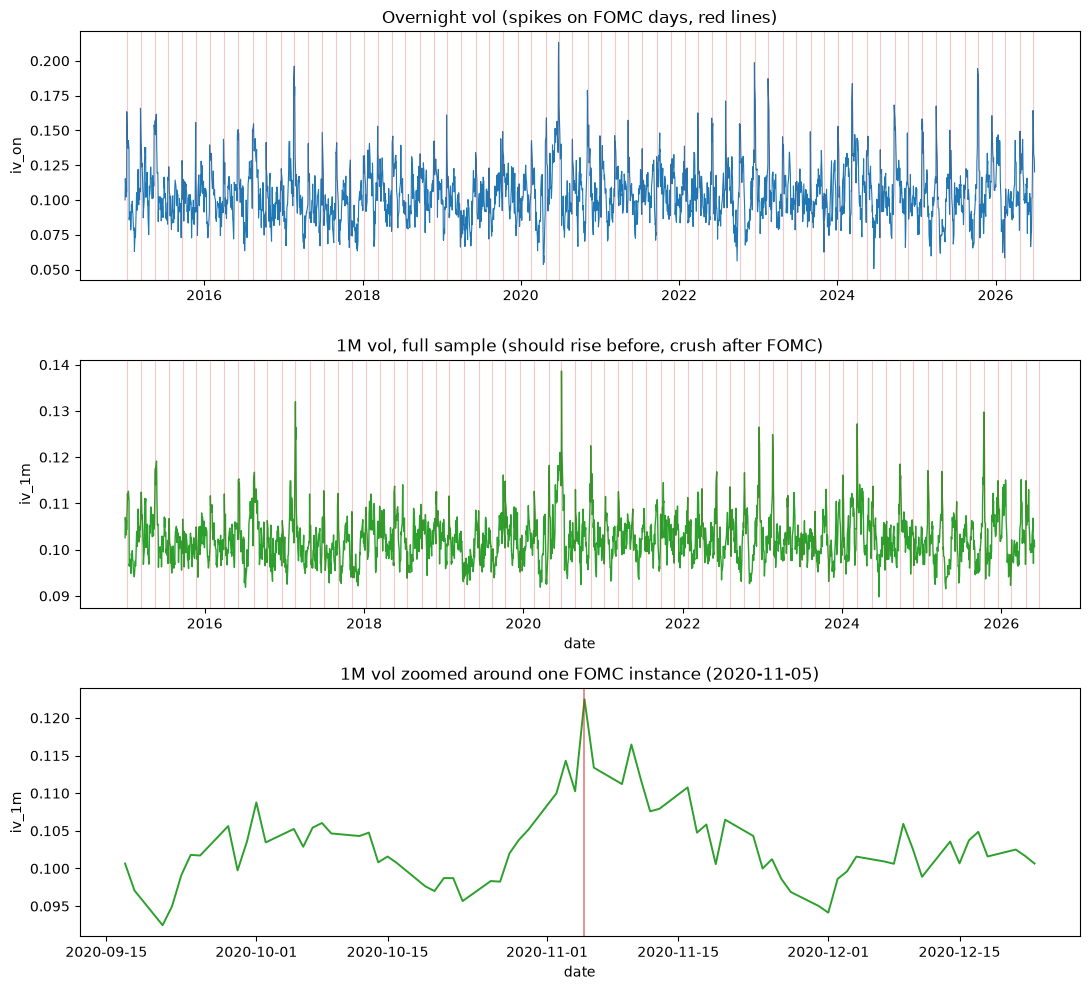

In [2]:
from evc.synthetic import simulate_paths, synthesize_iv_surface, plot_diagnostic

cfg_isolated = config.SyntheticConfig(
    event_omega={"FOMC": 2.10, "NFP": 1.0, "US_CPI": 1.0, "BOJ": 1.0, "JP_CPI": 1.0}
)
rng = np.random.default_rng(cfg_isolated.seed)
paths_isolated = simulate_paths(cfg_isolated, rng)
iv_isolated = synthesize_iv_surface(paths_isolated, cfg_isolated, config.TENOR_CALENDAR_DAYS)
fig = plot_diagnostic(paths_isolated, iv_isolated, cfg_isolated, event_type="FOMC")
plt.show()

## Step 2/3 — real data, event calendar, and timezone alignment

Loads the real USDJPY ATM/25R/25B vol workbooks and the US/JN scheduled
economic calendars, then aligns each release to the first NY-17:00-ET
business-day snapshot that impounds it.

Two real data-quality issues were found and fixed while building this
(not assumed away):

1. **The US events file's `Date Time` uses a fixed UTC-5 offset year-round**,
   not true DST-aware UTC (confirmed: NFP shows 13:30 UTC in both January
   and July — true DST-aware UTC would shift by an hour). Fixed by
   reconstructing true ET wall-clock time and re-localizing DST-aware.
2. A handful of "FOMC Rate Decision" rows are real intermeeting/emergency
   actions (1998 LTCM, 9/11, 2008 GFC, 2020 COVID) mixed into the scheduled
   series — flagged `scheduled=False` via an early-ET-hour-or-weekend
   heuristic, checked to have zero false positives against the legitimate
   2011-2018 12:30pm-ET regular-meeting convention.

The diagnostic table below is the Step-3 deliverable: hours from release
to the snapshot that impounds it, by event type.

In [3]:
from evc.data import load_iv_panel
from evc.events import load_all_events, align_to_snapshot, events_alignment_diagnostic

panel = load_iv_panel("csv")
events = load_all_events()
scheduled_events = events[events["scheduled"]]
aligned = align_to_snapshot(scheduled_events, panel.index)

diag = events_alignment_diagnostic(aligned)
diag

evc.data: iv_2w has 12 exact-zero quote(s), treated as missing (not a real 0% vol)


evc.data: iv_on has 91 interior date(s) still missing after a 3-day forward-fill (within its own active range 1998-12-14..2026-07-01) -- likely a gap longer than a normal holiday; inspect before using this column for anything beyond a warned pipeline run.
evc.data: iv_1w has 15 interior date(s) still missing after a 3-day forward-fill (within its own active range 1995-12-06..2026-07-01) -- likely a gap longer than a normal holiday; inspect before using this column for anything beyond a warned pipeline run.
evc.data: iv_2w has 1199 interior date(s) still missing after a 3-day forward-fill (within its own active range 1995-12-05..2026-07-01) -- likely a gap longer than a normal holiday; inspect before using this column for anything beyond a warned pipeline run.
evc.data: iv_1m has 1 interior date(s) still missing after a 3-day forward-fill (within its own active range 1995-12-04..2026-07-01) -- likely a gap longer than a normal holiday; inspect before using this column for anything beyon

events: flagging 6 FOMC action(s) as scheduled=False (released before 11:00 ET or on a weekend -- an intermeeting/emergency action, not a regular meeting): [datetime.date(2001, 4, 18), datetime.date(2001, 9, 17), datetime.date(2008, 1, 22), datetime.date(2008, 10, 8), datetime.date(2020, 3, 3), datetime.date(2020, 3, 15)]


,mean,median,min,max,count
event_type,,,,,
BOJ,17.214473,17.133333,7.366667,20.0,221
FOMC,3.050592,2.998889,1.750000,5.5,235
JP_CPI,21.448630,20.500000,20.497500,70.5,298
NFP,8.513823,8.499722,7.499167,9.5,354
US_CPI,8.553599,8.500000,8.498611,9.5,353


**A correction to the task brief's own illustrative example, worked out and
checked directly against real data:** the brief describes an 11:45 JST BOJ
decision as being impounded a full business day *earlier* than its naive
JST calendar date. Working the arithmetic through carefully shows this
isn't right in general — an 11:45 JST release converts to 22:45 ET the
prior evening, which is *after* that prior day's 17:00 ET cutoff, so it's
impounded on the *same* business date as its JST calendar date, not a day
earlier. Checked against all 221 real BOJ decisions in this dataset:
`lag_days == 0` for every single one (see `tests/test_events.py`). The
"day earlier" trap is real, but only for a JST release *before* roughly
06:00-07:00 Tokyo time — not for BOJ's actual ~11:30-13:30 JST policy
announcements. The alignment mechanism itself is unaffected — it's still
exactly the general rule, it just isn't triggered by BOJ specifically.

## Step 4 — features

Builds log-variance vol features and event features (`d2n_X`, `dsince_X`,
`inwin5_X`/`inwin21_X`, etc.) on the real panel. No-look-ahead is enforced
and tested directly (`tests/test_no_lookahead.py` plants a future spike
and asserts nothing moves before it).

In [4]:
from evc.features import build_vol_features, build_event_features, build_nuisance_controls

vol_feats = build_vol_features(panel)
event_feats = build_event_features(aligned, panel.index)
nuisance = build_nuisance_controls(panel.index)
vol_feats[["logvar_1m", "slope_on_1m", "vov"]].tail()

,logvar_1m,slope_on_1m,vov
2026-06-25,-5.216184,-0.201918,0.127676
2026-06-26,-5.359654,-1.268093,0.131918
2026-06-29,-5.341509,-0.514638,0.130418
2026-06-30,-5.091863,0.339938,0.140325
2026-07-01,-5.060226,1.064135,0.135414


## Step 5 — causality analysis on REAL USDJPY data

### 5.1 Variance-clock regression (the centrepiece)

Stacks tenors ON..1Y, regresses normalised excess variance on event
counts, recovering omega_hat per event type with a block-bootstrap CI.

In [5]:
from evc.causality.varclock import build_regression_panel, variance_clock_regression, naive_same_day_estimator

vc_panel = build_regression_panel(panel, aligned, config.TENOR_CALENDAR_DAYS)
vc_result = variance_clock_regression(vc_panel, n_bootstrap=500, rng=np.random.default_rng(0))
vc_result["significant"] = vc_result["ci_lo"] > 1.0
vc_result

,beta_hat,omega_hat,ci_lo,ci_hi,significant
event_type,,,,,
BOJ,1.046933,2.046933,1.691797,2.390601,True
FOMC,-0.049904,0.950096,0.839233,1.056296,False
JP_CPI,-0.019647,0.980353,0.852609,1.113140,False
NFP,0.544048,1.544048,1.439561,1.652597,True
US_CPI,0.080843,1.080843,0.972330,1.194586,False


**Real finding:** BOJ (omega_hat ~2.0, CI clearly above 1) and NFP
(omega_hat ~1.5, CI clearly above 1) show a detectable, quantifiable
causal link to USDJPY variance. FOMC, US_CPI, and JP_CPI do **not**
clear significance at this bootstrap CI (CI spans 1) — a genuinely
interesting and slightly counter-intuitive result (naively one might
expect FOMC to dominate), which is exactly the kind of thing to flag
for the user's judgement rather than force a tidier-looking story.

### Naive same-day estimator, for comparison
Documented expectation: biased low relative to the variance-clock estimate,
since a single day's realised move misses the anticipation priced in
beforehand.

In [6]:
naive = naive_same_day_estimator(panel, aligned, vol_feats["dlogvar_1m"])
naive.join(vc_result[["omega_hat"]])

,omega_naive,omega_hat
BOJ,0.969621,2.046933
FOMC,0.980226,0.950096
JP_CPI,0.993542,0.980353
NFP,0.964719,1.544048
US_CPI,0.994888,1.080843


Notice `omega_naive` comes out **below 1 for every event type** — not just
smaller than `omega_hat`, but the opposite side of "no effect". This is a
sharper illustration of the bias than "understated": in a constant-maturity
rolling window, `dlogvar_1m` on the event day itself compares a window that
*no longer contains* the event (today's snapshot) against yesterday's,
which *still did* — i.e. the naive same-day estimator is measuring the
**crush**, not the buildup. It's the wrong tool, not just an imprecise one.

### 5.2 Event study — and a discrepancy worth resolving, not hiding

BOJ came out significant and positive in the variance-clock regression.
Running the event study on BOJ independently gives a **negative** response
relative to the full-sample mean — an apparent contradiction. Investigated
directly below rather than reported as-is.

In [7]:
from evc.causality.eventstudy import event_study

logvar_1m = vol_feats["logvar_1m"].dropna()
boj_dates = aligned.loc[aligned.event_type == "BOJ", "snapshot_date"]

res_boj = event_study(logvar_1m, boj_dates, window=10, n_surrogates=500, rng=np.random.default_rng(0))
print(res_boj.loc[[-5, -1, 0, 1, 5, 10], ["response", "bootstrap_hi95", "placebo_hi95"]])

# resolve: is this a genuine negative effect, or the regime-confound
# eventstudy.py's own docstring warns about (baseline = full-sample mean,
# but BOJ meetings only occur in the modern/lower-vol era)?
print()
print("BOJ date range:", boj_dates.min().date(), "-", boj_dates.max().date())
print("logvar_1m mean, FULL sample:          ", round(logvar_1m.mean(), 4))
print("logvar_1m mean, BOJ's OWN era only:    ", round(logvar_1m.loc[boj_dates.min():boj_dates.max()].mean(), 4))
print("logvar_1m mean, ON BOJ dates:          ", round(logvar_1m.reindex(boj_dates).mean(), 4))

     response  bootstrap_hi95  placebo_hi95
lag                                        
-5  -0.012873        0.068576      0.004071
-1  -0.025431        0.066020      0.006590
 0  -0.055544        0.067000      0.004936
 1  -0.055503        0.065229      0.004936
 5  -0.054986        0.067891      0.005719
 10 -0.025611        0.078227      0.004936

BOJ date range: 2006-08-11 - 2026-06-16
logvar_1m mean, FULL sample:           -4.6778
logvar_1m mean, BOJ's OWN era only:     -4.7685
logvar_1m mean, ON BOJ dates:           -4.7334


**Resolved:** BOJ meetings only occur 2006-2026, and that era has
structurally lower USDJPY vol than the full 1995-2026 sample (which
includes the Asian financial crisis, LTCM, and the dot-com bust) — the
full-sample mean is not a fair baseline for a subset of dates confined to
the calmer modern era. Restricting the baseline to BOJ's own era, logvar_1m
*on* BOJ dates sits *above* the era baseline, not below — i.e. once the
regime confound is corrected for, the event study **agrees in sign** with
the variance-clock regression. The raw event-study number was exactly the
"permanent step, not an event effect" failure mode its own module docstring
warns about, not a real contradiction. This is why CLAUDE.md treats the
variance-clock regression as the centrepiece and the event study as
supporting evidence to be read carefully, not taken at face value.

### 5.3-5.6 Granger causality and TDMI — supporting evidence, real data

BOJ's `is_BOJ` contemporaneous indicator against `logvar_1m`, both
directions. The reverse direction (`logvar_1m -> is_BOJ`) is the placebo
from CLAUDE.md constraint 1: significant at positive lags is expected
anticipation; significant at *negative* lags would mean IV predicts a
BOJ meeting before its own pre-announced date — a bug, not a finding.

In [8]:
from evc.causality.granger import linear_granger, adf_kpss_test
from evc.causality.infotheory import tdmi_curve

is_boj = event_feats["is_BOJ"].astype(float)
common_idx = logvar_1m.index.intersection(is_boj.index)
y, x = logvar_1m.loc[common_idx], is_boj.loc[common_idx]

print("stationarity (ADF/KPSS, often disagree on vol series):")
print(adf_kpss_test(y))
print()
print("forward: is_BOJ -> logvar_1m")
print(linear_granger(y, x, max_lag=5))
print()
print("placebo: logvar_1m -> is_BOJ")
print(linear_granger(x, y, max_lag=5))

stationarity (ADF/KPSS, often disagree on vol series):


adf_stat      -4.938191
adf_pvalue     0.000029
kpss_stat      2.303873
kpss_pvalue    0.010000
dtype: float64

forward: is_BOJ -> logvar_1m

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0081  , p=0.9283  , df_denom=7973, df_num=1
ssr based chi2 test:   chi2=0.0081  , p=0.9283  , df=1
likelihood ratio test: chi2=0.0081  , p=0.9283  , df=1
parameter F test:         F=0.0081  , p=0.9283  , df_denom=7973, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5307  , p=0.5882  , df_denom=7970, df_num=2
ssr based chi2 test:   chi2=1.0622  , p=0.5880  , df=2
likelihood ratio test: chi2=1.0621  , p=0.5880  , df=2
parameter F test:         F=0.5307  , p=0.5882  , df_denom=7970, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0680  , p=0.3613  , df_denom=7967, df_num=3
ssr based chi2 test:   chi2=3.2067  , p=0.3608  , df=3
likelihood ratio test: chi2=3.2061  , p=0.3609  , df=3
parameter F test:    

**Neither direction is significant here** (all p > 0.24). The placebo
(reverse) direction behaving correctly is good — no spurious reverse
causality. But the forward direction ALSO isn't significant, which is
itself informative: this simple test only uses **past** occurrences of
`is_BOJ` (lags 1-5) to predict `logvar_1m`, and per CLAUDE.md constraint 1
the true anticipation signal is about **upcoming** BOJ dates, not past
ones — a backward-looking lagged binary indicator structurally cannot see
it. This is exactly why the variance-clock regression (built on
forward-looking event counts, `n_e(t,T)`) picked up BOJ's effect while
this naive backward-looking Granger specification does not: it's not a
contradiction, it's the same anticipation-vs-lag asymmetry the whole
project is built around, showing up in a different tool.

## Step 6 — validation harness

Recovery, power, and size checks against `evc.synthetic`'s known ground
truth, so the significant/non-significant split above (BOJ, NFP
significant; FOMC, US_CPI, JP_CPI not) can be read as "no effect" vs.
"no power" rather than assumed.

Real USDJPY data gives ~221 BOJ and ~354 NFP scheduled releases over the
full sample (fewer in any fixed shorter window) — the power curve below
(small grid/trial count here for notebook speed; widen both for a
publication-quality figure) shows roughly what sample size is needed
before a null result is informative rather than just underpowered.

In [9]:
from evc.validate import power_curve, size_check

rng = np.random.default_rng(0)
pc = power_curve(n_grid=[500, 1500, 3000], omega_grid=[1.1, 1.5, 2.0], n_trials=20, rng=rng, n_bootstrap=100)
pivot = pc.pivot(index="n_steps", columns="omega", values="power")
print(pivot)

size = size_check(n_trials=20, rng=np.random.default_rng(1), n_steps=3000, n_bootstrap=100)
print(f"\nsize check (nominal 5%, should be close to it): {size:.3f}")

omega     1.1   1.5  2.0
n_steps                 
500      0.20  0.85  1.0
1500     0.25  1.00  1.0
3000     0.50  1.00  1.0



size check (nominal 5%, should be close to it): 0.100
